<a href="https://colab.research.google.com/github/JoseAlberto88/Renewable-Energy-Transition-and-Carbon-Emissions/blob/main/Collecting_Data_Applying_PESTEL_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

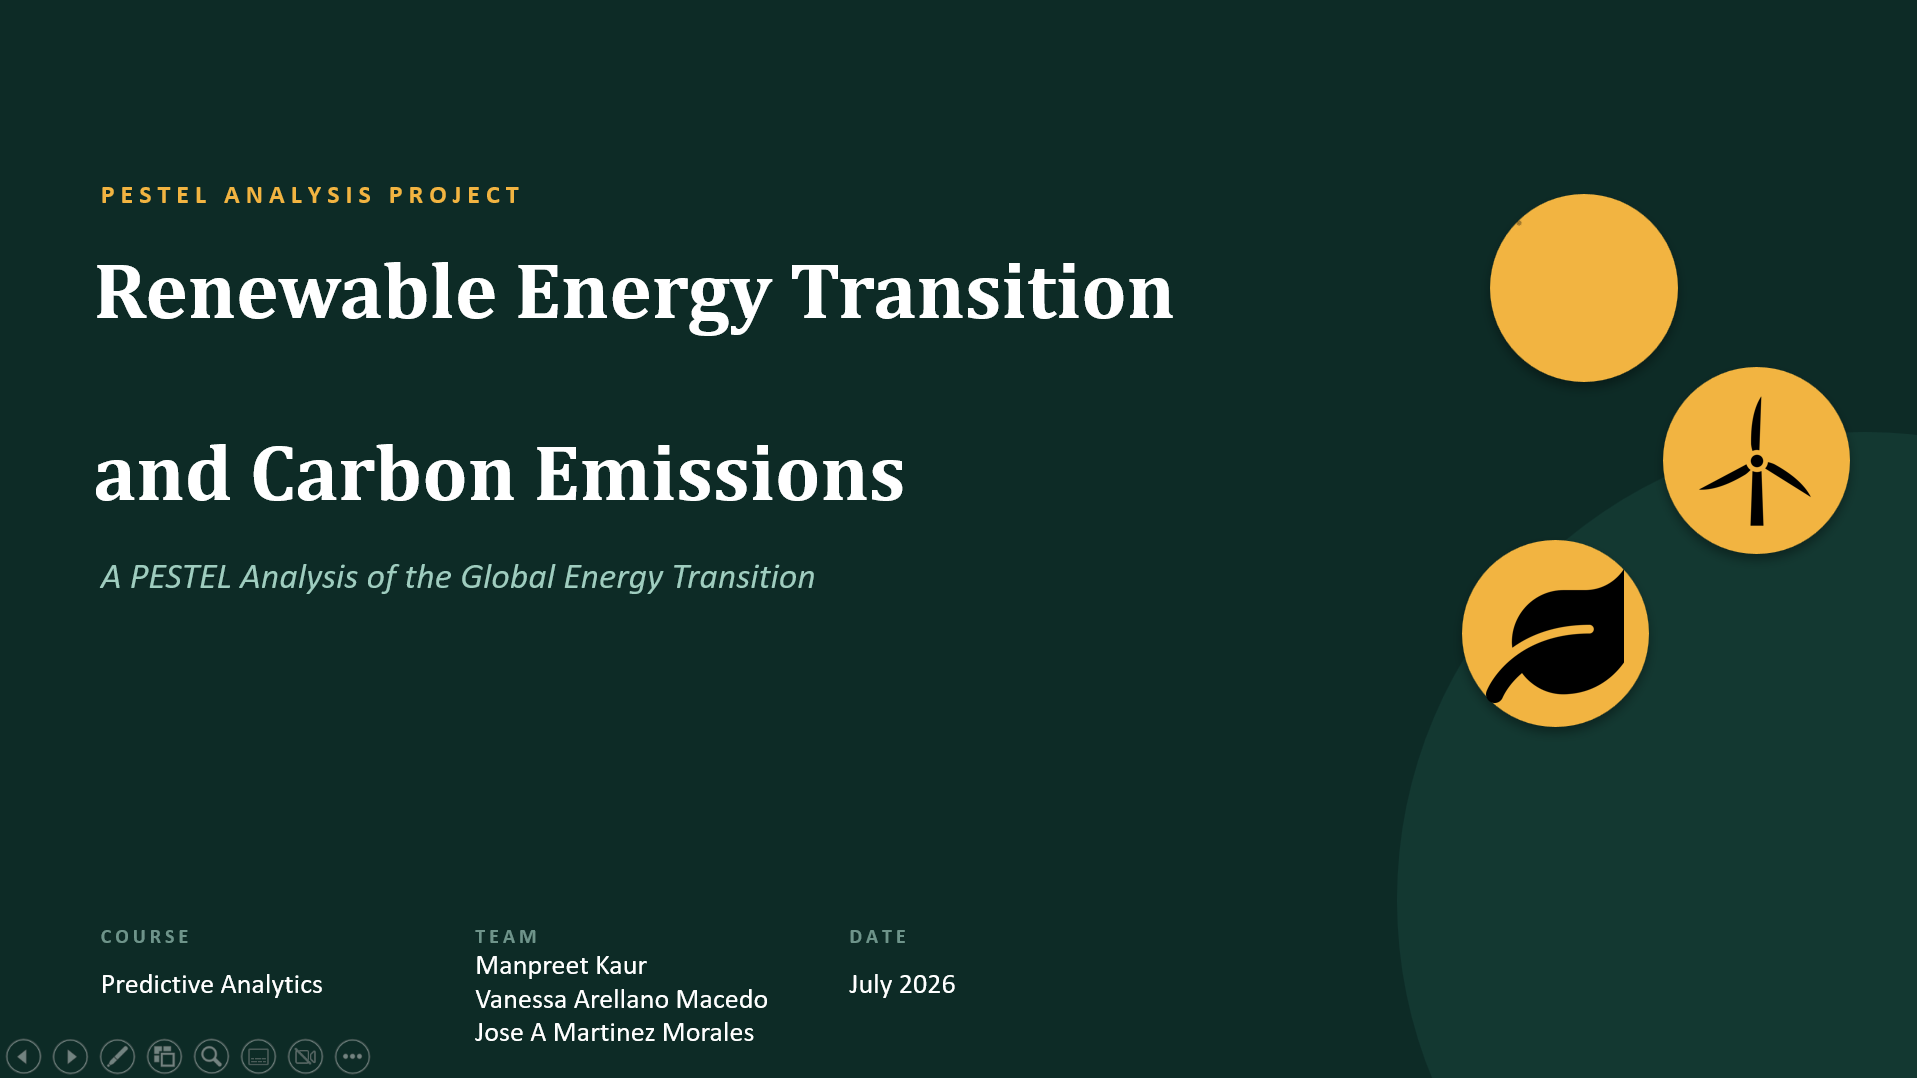

# Part 1: Data Collection & Preparation
## Renewable Energy Transition and Carbon Emissions. A PESTEL Analysis

---

## 1. Project Overview

This project examines the global **renewable energy transition** and its relationship to **carbon emissions**, using a PESTEL framework to structure the analysis. Part 1 focuses on collecting, cleaning, and consolidating real secondary data into a single analytical dataset that will support the modeling and insights developed in later parts of the project.

The guiding question behind the dataset is:

> *How do economic performance and technological progress in renewable energy relate to a country's carbon emissions over time?*

To answer this, we selected **three PESTEL components**. Economic, Technological, and Environmental. Each represented by real, publicly available secondary data.

---

## 2. Selected PESTEL Components

| PESTEL Component | Why It Was Selected |
|---|---|
| **Economic** | GDP per capita growth reflects a country's overall economic momentum, which shapes its capacity to invest in energy infrastructure and its energy demand. |
| **Technological** | Renewable, solar, and wind installed capacity are the clearest technological indicators of how far a country has progressed in adopting clean energy technology. |
| **Environmental** | CO₂ emissions per capita is the outcome variable of interest — it captures the environmental impact that economic activity and energy technology choices are ultimately trying to reduce. |

Three components were chosen (rather than all six) because they map directly onto the core research question: **economic capacity → technological adoption → environmental outcome**. Political, Social, and Legal factors, while relevant to the broader energy transition story, are not required for this stage and were left out to keep the dataset focused and analytically coherent.

---

## 3. Data Sources

| Data Source | PESTEL Component | Variable(s) Extracted |
|---|---|---|
| **World Bank** | Economic | GDP per capita growth (%) |
| **IRENA** (International Renewable Energy Agency) | Technological | Renewable capacity (MW), Solar capacity (MW), Wind capacity (MW) |
| **Our World in Data** | Environmental | CO₂ emissions per capita (tonnes) |

Each source provides country-year level data, which allowed the three datasets to be merged into a single consolidated table using a common key: **ISO3 country code + year**.

---

## 4. Data Cleaning & Preparation

The three raw datasets differed substantially in structure, granularity, and coverage. The following steps were taken to bring them into a single, analysis-ready format:

### 4.1 Unit of Analysis
- Standardized to **one country, one year** across all sources.

### 4.2 Time Period
- Selected **2015–2023** as the common window, since this was the most recent period with consistent, complete coverage across all three sources and all selected variables. Later years were not uniformly available across every dataset.

### 4.3 Structural Reshaping
- **World Bank data** was converted from **wide to long format** (each year originally stored as a separate column), producing one row per country-year.
- **IRENA data** originally contained multiple rows per country-year, split by technology, sub-technology, and producer type. These were **filtered and aggregated** into a single consolidated country-year observation per capacity type (renewable, solar, wind).

### 4.4 Identifiers
- Country identifiers were standardized to **ISO3 codes** across all three sources to ensure a reliable merge key.

### 4.5 Merging
- Datasets were merged using a **composite key: ISO3 code + Year**.

### 4.6 Completeness Filtering
- Retained only countries with **complete data for every selected variable, across every year** in the 2015–2023 window.
- **Excluded territories** (e.g., non-sovereign or dependent territories) to preserve a consistent country-level unit of analysis.

### 4.7 Derived Variables
- Added a **Region** variable to support geographic comparisons and future dashboard filtering.
- Added **Renewable Capacity per Capita** to enable fair comparisons between countries of very different population sizes, rather than relying on absolute capacity alone.

### 4.8 Quality Checks
- Verified the final dataset for:
  - **Missing values** (none remaining)
  - **Duplicated country-year records** (none found)

No outlier treatment was required at this stage, as the variables (growth rates, installed capacity, emissions per capita) fall within expected real-world ranges once territories and incomplete-coverage countries were excluded.

---

## 5. Final Dataset Overview

| Attribute | Detail |
|---|---|
| **Unit of analysis** | One country, one year |
| **Time range** | 2015–2023 (9 years) |
| **Countries** | 115 |
| **Observations** | 1,035 country-year rows |
| **Variables** | 10 |
| **Missing values** | None |
| **Duplicate country-year records** | None |

### 5.1 Variable Dictionary

| Variable | Description | PESTEL Component |
|---|---|---|
| `Country` | Country name | — |
| `ISO3_Code` | ISO3 country identifier (merge key) | — |
| `Region` | Geographic region | — |
| `Year` | Observation year (2015–2023) | — |
| `GDP_Per_Capita_Growth_Pct` | GDP per capita growth (%) | Economic |
| `Renewable_Capacity_MW` | Total installed renewable capacity (MW) | Technological |
| `Solar_Capacity_MW` | Installed solar capacity (MW) | Technological |
| `Wind_Capacity_MW` | Installed wind capacity (MW) | Technological |
| `Renewable_Capacity_Per_Capita_W` | Renewable capacity per capita (Watts/person) | Technological |
| `CO2_Emissions_Per_Capita` | CO₂ emissions per capita (tonnes) | Environmental |

### 5.2 PESTEL Mapping Summary

- **Economic (1 variable):** GDP per capita growth
- **Technological (4 variables):** Renewable, solar, and wind capacity, plus capacity per capita
- **Environmental (1 variable):** CO₂ emissions per capita

The imbalance in variable count across components is intentional: the Technological component required more granular indicators to capture different dimensions of renewable adoption (total, source-specific, and population-adjusted), while Economic and Environmental components are each represented by a single, well-established headline indicator sufficient for the analysis.

---

## 6. Files Delivered

- `Renewable_Energy_PESTEL_Cleaned_115_Countries.csv`
- `Renewable_Energy_PESTEL_Cleaned_115_Countries.xlsx`

In [ ]:
# All the datasets were saving using my personal googe drive account.
# Lets call them and import the datasets to this envoriment
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# To knowing exactly what is inside of this directory
import os
folder = '/content/drive/MyDrive/Predictive Analytics Course'
for f in os.listdir(folder):
    print(f)

Renewable_Energy_PESTEL_Cleaned_115_Countries.csv
BostonHousing.csv
student_placement_data.csv
co-emissions-per-capita.csv
GPD per capital.xls
IRENA_Stats_Tool_v2.xlsb
PESTEL_renewable_energy_consolidated.csv
Case_study_2.ipynb


It is necessary to install the xlrd library since one of the file is coding in a binary form.

In [5]:
# Installing the package and creating a name to the folder directory
!pip install xlrd pyxlsb -q

import pandas as pd

FOLDER = '/content/drive/MyDrive/Predictive Analytics Course'

**Notice:**

The following steps helps us to clean the datasets. A previous jupyter notebook was created to check any inconsistencies, so now we are going directly to clean the dataset and give a little description about each step.

**Clean World Bank GDP data (Economic FESTEL Framework)**

In [9]:
# Importing the dataset and called it wb as a DataFrame
wb = pd.read_excel(f'{FOLDER}/GPD per capital.xls', sheet_name='Data', header=3, engine='xlrd')
wb_meta = pd.read_excel(f'{FOLDER}/GPD per capital.xls', sheet_name='Metadata - Countries', engine='xlrd')

# Wide then long (one row per country-year)
year_cols = [c for c in wb.columns if str(c).isdigit()]
wb_long = wb.melt(id_vars=['Country Name', 'Country Code'], value_vars=year_cols,
                   var_name='Year', value_name='GDP Per_Capita_Growth_Pct')
wb_long['Year'] = wb_long['Year'].astype(int)
wb_long = wb_long.rename(columns={'Country Code': 'ISO3_Code'})

# Keep only real countries. WB aggregates (World, regions, income groups) have a blank Region
real_countries = wb_meta[wb_meta['Region'].notna()][['Country Code', 'Region']].rename(columns={'Country Code': 'ISO3_Code'})
wb_long = wb_long.merge(real_countries, on='ISO3_Code', how='inner')
wb_long = wb_long[(wb_long['Year'] >= 2015) & (wb_long['Year'] <= 2023)]

print(wb_long.shape)
wb_long.head()

(1953, 5)


,Country Name,ISO3_Code,Year,GDP Per_Capita_Growth_Pct,Region
11935,Aruba,ABW,2015,2.556218,Latin America & Caribbean
11936,Afghanistan,AFG,2015,-1.665057,Middle East & North Africa
11937,Angola,AGO,2015,-2.804708,Sub-Saharan Africa
11938,Albania,ALB,2015,3.817434,Europe & Central Asia
11939,Andorra,AND,2015,3.630798,Europe & Central Asia


**Clean IRENA capacity data (Technological PESTEL Framework)**

In [11]:
# Importing the data and using the new package.
irena_raw = pd.read_excel(f'{FOLDER}/IRENA_Stats_Tool_v2.xlsb', sheet_name='Data', engine='pyxlsb', header=5)
irena_raw = irena_raw[irena_raw['Year'].notna()]
irena_raw['Year'] = irena_raw['Year'].astype(int)
irena_raw = irena_raw[(irena_raw['Year'] >= 2015) & (irena_raw['Year'] <= 2023)]

ren = irena_raw[irena_raw['RE or Non-RE'] == 'Total Renewable']

# Total renewable capacity (MW) — sum installed capacity across sub-technologies/producer types.
# "All types" rows carry no capacity value (they only carry the per-capita indicator below),
# so summing with min_count=1 double-counts nothing.
total_cap = (ren.groupby(['Country', 'ISO3 code', 'Year'])['Electricity Installed Capacity (MW)']
             .sum(min_count=1).reset_index()
             .rename(columns={'Electricity Installed Capacity (MW)': 'Renewable_Capacity_MW'}))

solar_cap = (ren[ren['Group Technology'] == 'Solar energy']
             .groupby(['Country', 'ISO3 code', 'Year'])['Electricity Installed Capacity (MW)']
             .sum(min_count=1).reset_index()
             .rename(columns={'Electricity Installed Capacity (MW)': 'Solar_Capacity_MW'}))

wind_cap = (ren[ren['Group Technology'] == 'Wind energy']
            .groupby(['Country', 'ISO3 code', 'Year'])['Electricity Installed Capacity (MW)']
            .sum(min_count=1).reset_index()
            .rename(columns={'Electricity Installed Capacity (MW)': 'Wind_Capacity_MW'}))

# Renewable capacity per capita (W/inhabitant) — IRENA's own SDG 7b1 indicator,
# summed across group technologies at the "All types" aggregation level
percap = (ren[ren['Producer Type'] == 'All types']
          .groupby(['Country', 'ISO3 code', 'Year'])['SDG 7b1 RE capacity per capita (W/inhabitant)']
          .sum(min_count=1).reset_index()
          .rename(columns={'SDG 7b1 RE capacity per capita (W/inhabitant)': 'Renewable_Capacity_Per_Capita_W'}))

irena = (total_cap.merge(solar_cap, on=['Country', 'ISO3 code', 'Year'], how='left')
                   .merge(wind_cap, on=['Country', 'ISO3 code', 'Year'], how='left')
                   .merge(percap, on=['Country', 'ISO3 code', 'Year'], how='left')
                   .rename(columns={'ISO3 code': 'ISO3_Code'}))

print(irena.shape)
irena.head()

(2101, 7)


,Country,ISO3_Code,Year,Renewable_Capacity_MW,Solar_Capacity_MW,Wind_Capacity_MW,Renewable_Capacity_Per_Capita_W
0,Afghanistan,AFG,2015,302.786,19.091,0.1,8.945026
1,Afghanistan,AFG,2016,350.304,21.16,0.1,10.067373
2,Afghanistan,AFG,2017,372.694,23.301,0.4,10.415945
3,Afghanistan,AFG,2018,372.469,23.076,0.4,10.111004
4,Afghanistan,AFG,2019,401.984,52.591,0.4,10.065057


**Clean Our World in DAta CO2 (Environmental PESTEL Framework)**

In [14]:
owid = pd.read_csv(f'{FOLDER}/co-emissions-per-capita.csv')
owid = owid.rename(columns={'Entity': 'Country', 'Code': 'ISO3_Code',
                             'CO₂ emissions per capita': 'CO2_Emissions_Per_Capita'})
owid = owid[owid['ISO3_Code'].notna()]  # drops OWID aggregates (World, continents, income groups)
owid = owid[(owid['Year'] >= 2015) & (owid['Year'] <= 2023)]

print(owid.shape)
owid.head()

(2034, 4)


,Country,ISO3_Code,Year,CO2_Emissions_Per_Capita
66,Afghanistan,AFG,2015,0.277384
67,Afghanistan,AFG,2016,0.248005
68,Afghanistan,AFG,2017,0.260895
69,Afghanistan,AFG,2018,0.277372
70,Afghanistan,AFG,2019,0.274727
